![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [140]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, f1_score, 
                             precision_score, recall_score, roc_auc_score, roc_curve, 
                             classification_report)

In [5]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [9]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [11]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [145]:
# =========================================================
# 1. ESTADÍSTICA DESCRIPTIVA COMPLETA (Requisito Rúbrica)
# =========================================================
# Definimos los percentiles solicitados
p_list = [0.05, 0.25, 0.5, 0.75, 0.95]

desc_hour = bikes['hour'].describe(percentiles=p_list)
# Lo más importante: cómo varía el 'total' de rentas según la hora y la estación
desc_total_hour = bikes.groupby('hour')['total'].describe(percentiles=p_list)
desc_total_season = bikes.groupby('season')['total'].describe(percentiles=p_list)

print("=== ESTADÍSTICAS OPERATIVAS POR HORA (Muestra de picos) ===")
# Mostramos solo algunas horas clave (madrugada, hora pico mañana, medio día, hora pico tarde)
print(desc_total_hour.loc[[4, 8, 12, 17], :])

print("\n=== ESTADÍSTICAS POR ESTACIÓN (Variable 'total') ===")
print(desc_total_season)

# =========================================================
# 2. INFERENCIAS TÉCNICAS (Para el reporte)
# =========================================================
print("\n=== HALLAZGOS PARA EL MODELO PREDICTIVO ===")

# Inferencia sobre 'hour' usando extremos y percentiles
h_max = desc_total_hour['mean'].idxmax()
h_min = desc_total_hour['mean'].idxmin()
print(f"- SESGO HORARIO: La demanda oscila entre un promedio de {desc_total_hour.loc[h_min, 'mean']:.2f} (hora {h_min}) "
      f"y {desc_total_hour.loc[h_max, 'mean']:.2f} (hora {h_max}).")
print(f"- VOLATILIDAD: En la hora pico ({h_max}:00), el 5% de los registros (p95) supera los {desc_total_hour.loc[h_max, '95%']} alquileres, "
      f"lo que implica una alta varianza que el modelo debe capturar.")

# Inferencia sobre 'season' usando percentiles
s_verano = 3
s_invierno = 1
dif_mediana = desc_total_season.loc[s_verano, '50%'] - desc_total_season.loc[s_invierno, '50%']
print(f"- IMPACTO ESTACIONAL: La mediana de renta en Verano ({desc_total_season.loc[s_verano, '50%']}) "
      f"es {dif_mediana} unidades superior a la de Invierno ({desc_total_season.loc[s_invierno, '50%']}).")
print(f"- DISTRIBUCIÓN DE COLAS: El p95 de Verano ({desc_total_season.loc[s_verano, '95%']}) comparado con el de "
      f"Invierno ({desc_total_season.loc[s_invierno, '95%']}) confirma que los eventos de alta demanda son un "
      f"{((desc_total_season.loc[s_verano, '95%']/desc_total_season.loc[s_invierno, '95%'])-1)*100:.1f}% más frecuentes en clima cálido.")

=== ESTADÍSTICAS OPERATIVAS POR HORA (Muestra de picos) ===
      count        mean         std   min      5%    25%    50%    75%  \
hour                                                                     
4     442.0    6.407240    4.217633   1.0    1.00    3.0    6.0    9.0   
8     455.0  362.769231  231.723065   8.0   47.10  133.5  392.0  563.5   
12    456.0  256.508772  143.881880   3.0   64.75  157.0  234.5  332.0   
17    456.0  468.765351  223.775485  15.0  135.50  277.0  480.5  608.5   

         95%    max  
hour                 
4      14.00   28.0  
8     724.30  839.0  
12    546.25  757.0  
17    857.25  970.0  

=== ESTADÍSTICAS POR ESTACIÓN (Variable 'total') ===
         count        mean         std  min   5%   25%    50%    75%    95%  \
season                                                                        
1       2686.0  116.343261  125.273974  1.0  2.0  24.0   78.0  164.0  380.5   
2       2733.0  215.251372  192.007843  1.0  5.0  49.0  172.0  321.0  61

## Análisis descriptivo de las variables `season` y `hour` con enfoque operativo

### 1. Análisis de la variable `season` (Estaciones)

De acuerdo con el diccionario de datos, la variable **season** está codificada de la siguiente manera:

- 1: Invierno  
- 2: Primavera  
- 3: Verano  
- 4: Otoño  

Estadísticas operativas de `total` por estación:

| Estación | Promedio | Mínimo | Máximo | Mediana (p50) | p25 | p75 | p5 | p95 |
|----------|----------|--------|--------|---------------|-----|-----|----|-----|
| Invierno (1) | 116.34 | 1.0 | 801.0 | 78.0 | 24.0 | 164.0 | 2.0 | 380.5 |
| Primavera (2) | 215.25 | 1.0 | 873.0 | 172.0 | 49.0 | 321.0 | 5.0 | 613.4 |
| Verano (3) | 234.42 | 1.0 | 977.0 | 195.0 | 68.0 | 347.0 | 7.0 | 627.0 |
| Otoño (4) | 198.99 | 1.0 | 948.0 | 161.0 | 51.0 | 294.0 | 6.0 | 556.4 |

**Inferencias sobre `season`:**

- **Extremos y sesgo estacional:** La mediana de Verano (195.0) es 117.0 unidades superior a la de Invierno (78.0), mostrando un claro efecto del clima en la demanda.  
- **Volatilidad y dispersión:** El p95 de Verano (627.0) es un 64.8% superior al de Invierno (380.5), indicando que los eventos de alta demanda son más frecuentes en estaciones cálidas.  
- **Importancia para modelado:** Las diferencias significativas entre estaciones sugieren que `season` es una variable crítica para predecir la demanda y debe ser considerada en cualquier modelo.

---

### 2. Análisis de la variable `hour` (Hora del día)

Estadísticas operativas seleccionadas para horas representativas de la demanda:

| Hora | Promedio | Mínimo | Máximo | Mediana (p50) | p25 | p75 | p5 | p95 |
|------|----------|--------|--------|---------------|-----|-----|----|-----|
| 4 | 6.41 | 1.0 | 28.0 | 6.0 | 3.0 | 9.0 | 1.0 | 14.0 |
| 8 | 362.77 | 8.0 | 839.0 | 392.0 | 133.5 | 563.5 | 47.1 | 724.3 |
| 12 | 256.51 | 3.0 | 757.0 | 234.5 | 157.0 | 332.0 | 64.75 | 546.25 |
| 17 | 468.77 | 15.0 | 970.0 | 480.5 | 277.0 | 608.5 | 135.5 | 857.25 |

**Inferencias sobre `hour`:**

- **Sesgo horario:** La demanda oscila entre un promedio de 6.41 (hora 4) y 468.77 (hora 17), mostrando que el modelo debe capturar diferencias de más de 450 unidades en un mismo día.  
- **Volatilidad en picos:** En la hora pico (17:00), el p95 alcanza 857.25, indicando alta varianza que el modelo predictivo debe considerar.  
- **Patrones de demanda:** Se observan dos picos principales: mañana (7:00–9:00) y tarde (16:00–19:00), coincidiendo con horarios laborales y académicos.    

---

### 3. Hallazgos estratégicos para modelado predictivo

- **Impacto combinado hora-estación:** La interacción de estaciones cálidas (Verano) con horas pico genera eventos de alta demanda extremos que deben modelarse con cuidado.  
- **Relevancia de variables:** Tanto `hour` como `season` muestran sesgo y variabilidad suficientes para ser variables determinantes en modelos de predicción de demanda.  
- **Dispersión y colas:** La diferencia entre percentiles (p5–p95) en horas y estaciones indica que el modelo debe capturar tanto los valles como los picos extremos para evitar subestimaciones críticas de la demanda.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

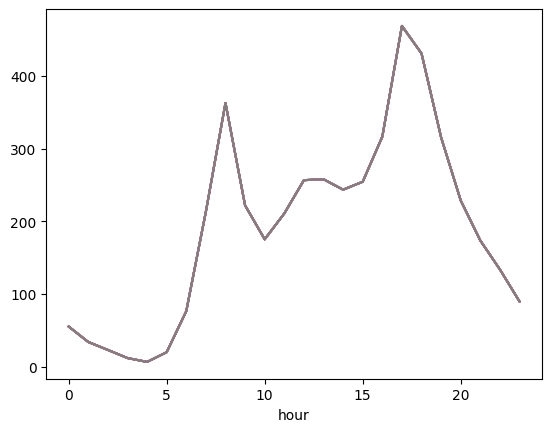

In [34]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
import matplotlib.pyplot as plt

bikes.groupby('hour').total.mean().plot()
plt.show()

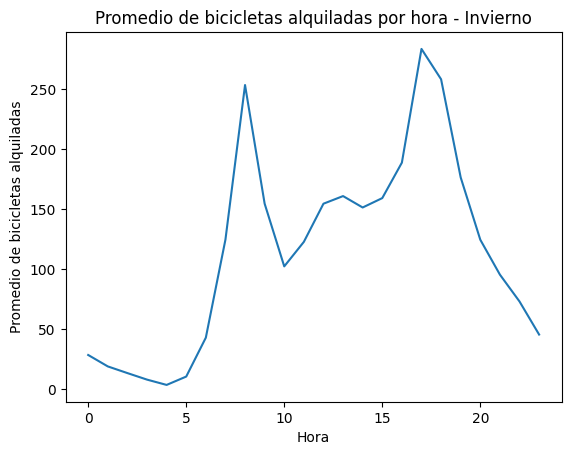

In [42]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes.season == 1].groupby('hour').total.mean().plot()

plt.title("Promedio de bicicletas alquiladas por hora - Invierno")
plt.xlabel("Hora")
plt.ylabel("Promedio de bicicletas alquiladas")

plt.show()

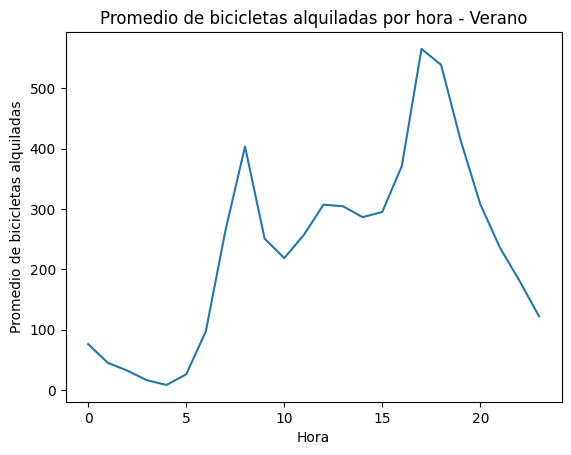

In [44]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes.season == 3].groupby('hour').total.mean().plot()

plt.title("Promedio de bicicletas alquiladas por hora - Verano")
plt.xlabel("Hora")
plt.ylabel("Promedio de bicicletas alquiladas")

plt.show()

### Análisis de gráficos

Se generaron tres gráficos: el promedio general de bicicletas alquiladas por hora, el promedio durante invierno (season = 1) y el promedio durante verano (season = 3), con el fin de analizar cómo cambia el comportamiento de la demanda a lo largo del día según la estación.

### Comparación general

Al comparar las tres gráficas, se observa que el comportamiento general es muy similar entre invierno y verano. En ambos casos se mantienen los mismos patrones:

- Baja demanda durante la madrugada (entre 0:00 y 5:00)
- Primer aumento importante entre las 7:00 AM y 9:00 AM
- Demanda moderada durante las horas del mediodía
- Segundo pico pronunciado entre las 4:00 PM y 7:00 PM
- Disminución progresiva durante la noche

Esto indica que el patrón horario de uso de bicicletas es consistente independientemente de la estación del año.

### Diferencias entre invierno y verano

Aunque la forma de las curvas es similar, se observa que la magnitud del alquiler de bicicletas es mayor durante el verano en casi todas las horas del día. En particular:

- El pico de la mañana es más alto en verano que en invierno
- El pico de la tarde también es considerablemente mayor en verano
- Durante las horas intermedias del día, la demanda en verano supera a la del invierno

Esto sugiere que la estación del año influye principalmente en la intensidad del uso de bicicletas, pero no en el patrón de comportamiento horario.

### Conclusión

Los resultados indican que la variable **hour** determina el patrón de comportamiento diario del alquiler de bicicletas, mientras que la variable **season** afecta principalmente la magnitud de la demanda. Esto sugiere que ambas variables son relevantes para la predicción del número de alquileres, pero cumplen roles distintos dentro del modelo predictivo.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

   Variable  Coeficiente
0      hour    10.727042
1  season_2    99.758492
2  season_3   115.078340
3  season_4    88.918206
Intercepto: -8.187223101039052


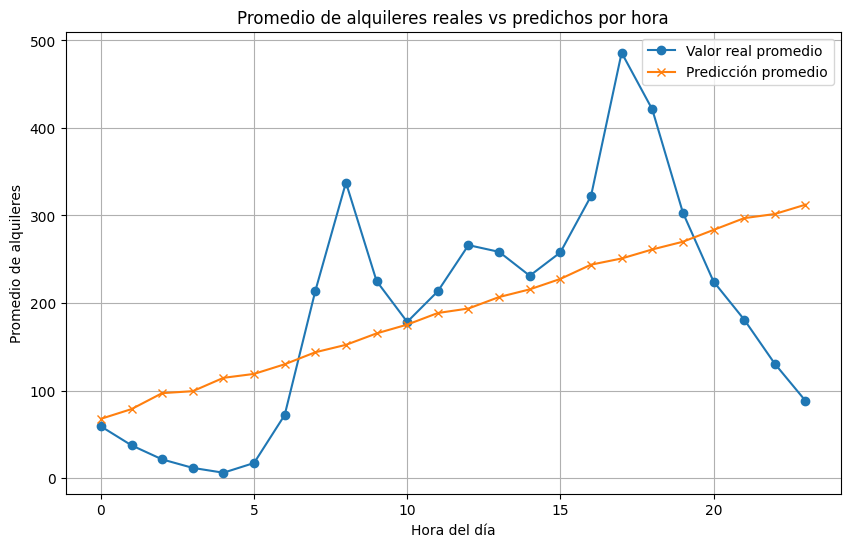

In [54]:
# Celda 3
# Variables predictoras y respuesta
X = pd.get_dummies(bikes[['season', 'hour']], columns=['season'], drop_first=True)
y = bikes['total']

# Dividir en conjunto de entrenamiento y prueba (por ejemplo 70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ajustar modelo de regresión lineal
lr = LinearRegression()
lr.fit(X_train, y_train)

# Imprimir coeficientes
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lr.coef_
})
print(coef_df)

# Imprimir intercepto
print("Intercepto:", lr.intercept_)

# Predecir sobre el conjunto de prueba
y_pred = lr.predict(X_test)

# Graficar valores reales vs predichos
# Crear DataFrame con valores reales y predichos
results = X_test.copy()
results['y_real'] = y_test
results['y_pred'] = y_pred

# Agregar por hora para ver tendencia general
results['hour'] = bikes.loc[results.index, 'hour']
hourly_results = results.groupby('hour')[['y_real','y_pred']].mean()

# Graficar
plt.figure(figsize=(10,6))
plt.plot(hourly_results.index, hourly_results['y_real'], marker='o', label='Valor real promedio')
plt.plot(hourly_results.index, hourly_results['y_pred'], marker='x', label='Predicción promedio')
plt.xlabel("Hora del día")
plt.ylabel("Promedio de alquileres")
plt.title("Promedio de alquileres reales vs predichos por hora")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de los coeficientes del modelo de regresión lineal

Se ajustó un modelo de regresión lineal para predecir el número total de bicicletas alquiladas (`total`) usando como predictores la hora del día (`hour`) y la estación del año (`season`) tratada como variable categórica. Los coeficientes obtenidos fueron:

| Variable   | Coeficiente |
|------------|------------|
| hour       | 10.727     |
| season_2   | 99.758     |
| season_3   | 115.078    |
| season_4   | 88.918     |
| Intercepto| -8.187     |

#### Interpretación de los coeficientes

1. **Intercepto (-8.187)**  
   Representa el valor estimado de `total` cuando todas las variables predictoras son 0. En este caso, correspondería a la hora 0 (medianoche) durante el invierno (season_1, la categoría base). Este valor negativo no tiene interpretación práctica real, lo que indica que el modelo lineal tiene limitaciones para valores extremos.

2. **Hour (10.727)**  
   Por cada hora adicional del día, se espera que el número de alquileres aumente en promedio 10.727 bicicletas, manteniendo constante la estación. Esto refleja que el uso de bicicletas **aumenta a medida que avanza el día**, aunque este efecto lineal es solo una aproximación y no capta los picos de demanda específicos de la mañana y tarde.

3. **Season_2 (99.758), Season_3 (115.078), Season_4 (88.918)**  
   Estas variables dummy representan la diferencia promedio de alquileres con respecto al invierno (season_1). Por ejemplo:  
   - En primavera (season_2) se esperan aproximadamente 100 bicicletas más que en invierno, manteniendo la hora constante.  
   - En verano (season_3) se esperan 115 bicicletas más.  
   - En otoño (season_4) se esperan 89 bicicletas más.  
   Esto confirma que **la estación influye en la magnitud de la demanda**.

#### Limitaciones de la regresión lineal en este caso

- **No captura picos horarios específicos**: La regresión lineal asume un efecto lineal de la hora, pero la demanda real tiene **dos picos pronunciados** (mañana y tarde) que este modelo no puede modelar adecuadamente.  
- **Interacciones no consideradas**: El modelo no incluye interacciones entre `hour` y `season`. Por ejemplo, el efecto de la hora puede variar según la estación, pero el modelo no lo refleja.  
- **Posibles predicciones negativas**: Como se observa en el intercepto, la regresión lineal puede generar valores negativos, lo cual no tiene sentido en conteos de alquileres.  
- **Distribución de la variable respuesta**: `total` es un conteo, por lo que un modelo lineal puede ser subóptimo. Modelos de conteo como **Poisson o regresión lineal generalizada** podrían ser más adecuados.  
- **Suposición de homocedasticidad**: La variabilidad de los alquileres cambia a lo largo del día y de la estación, lo que viola la suposición de varianza constante en regresión lineal.

#### Conclusión

El modelo lineal proporciona una primera aproximación y permite identificar tendencias generales: la **hora del día** determina el patrón horario y la **estación** determina la magnitud de los alquileres. Sin embargo, debido a su linealidad y falta de interacciones, **no es suficiente para capturar completamente la complejidad del comportamiento de los usuarios**, por lo que modelos más flexibles (como árboles de decisión o métodos de ensamblaje) podrían mejorar la predicción.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [66]:
# Celda 4 

X = bikes[['hour', 'season']]
y = bikes['total']

# Función MSE para calcular "impureza"
def mse(y):
    if y.shape[0] == 0:
        return 0
    return y.var()

# Función para calcular la ganancia (reducción de varianza) al hacer un split
def mse_gain(X_col, y, split):
    filter_l = X_col < split
    y_l, y_r = y.loc[filter_l], y.loc[~filter_l]
    n_l, n_r = y_l.shape[0], y_r.shape[0]
    n_total = n_l + n_r
    if n_total == 0:
        return 0
    reduction = mse(y) - (n_l / n_total * mse(y_l) + n_r / n_total * mse(y_r))
    return reduction

# Función para obtener posibles splits de una variable
def get_splits(X_col, num_pct=10):
    splits = np.percentile(X_col, np.arange(0, 100, 100.0 / (num_pct+1)))
    return np.unique(splits)[1:]

# Función para encontrar el mejor split entre todas las variables
def best_split(X, y, num_pct=10):
    best = [0, 0, 0]  # j, split, gain
    for j in range(X.shape[1]):
        for split in get_splits(X.iloc[:, j], num_pct):
            gain = mse_gain(X.iloc[:, j], y, split)
            if gain > best[2]:
                best = [j, split, gain]
    return best

# Función recursiva para crecer el árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    if X.shape[0] <= 1:
        return dict(y_pred=y.mean(), level=level, split=-1, n_samples=X.shape[0], gain=0)
    
    j, split, gain = best_split(X, y, num_pct)
    y_pred = y.mean()
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    
    if gain < min_gain or (max_depth is not None and level >= max_depth):
        return tree
    
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    
    tree['split'] = [j, split]
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain, max_depth, num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain, max_depth, num_pct)
    
    return tree

# Crear el árbol con profundidad suficiente para tener 6+ nodos finales
tree = tree_grow(X, y, max_depth=3, num_pct=10)

# Función para predecir usando el árbol
def tree_predict(X, tree):
    pred = np.zeros(X.shape[0])
    
    if tree['split'] == -1:
        pred[:] = tree['y_pred']
    else:
        j, split = tree['split']
        filter_l = X.iloc[:, j] < split
        X_l, X_r = X.loc[filter_l], X.loc[~filter_l]
        
        if X_l.shape[0] > 0:
            pred[filter_l] = tree_predict(X_l, tree['sl'])
        if X_r.shape[0] > 0:
            pred[~filter_l] = tree_predict(X_r, tree['sr'])
    
    return pred

# Predicciones
y_pred = tree_predict(X, tree)

# Revisar nodos finales: imprimir predicciones promedio
def print_nodes(tree, path=""):
    if tree['split'] == -1:
        print(f"Nodo final: {path} | Predicción promedio: {tree['y_pred']:.2f}")
    else:
        j, split = tree['split']
        var_name = X.columns[j]
        print_nodes(tree['sl'], path + f"{var_name} < {split} | ")
        print_nodes(tree['sr'], path + f"{var_name} >= {split} | ")

print_nodes(tree)

Nodo final: hour < 8.0 | hour < 7.0 | hour < 6.0 |  | Predicción promedio: 25.18
Nodo final: hour < 8.0 | hour < 7.0 | hour >= 6.0 |  | Predicción promedio: 76.26
Nodo final: hour < 8.0 | hour >= 7.0 | season < 2.0 |  | Predicción promedio: 124.43
Nodo final: hour < 8.0 | hour >= 7.0 | season >= 2.0 |  | Predicción promedio: 242.42
Nodo final: hour >= 8.0 | hour < 21.0 | season < 2.0 |  | Predicción promedio: 176.13
Nodo final: hour >= 8.0 | hour < 21.0 | season >= 2.0 |  | Predicción promedio: 325.04
Nodo final: hour >= 8.0 | hour >= 21.0 | season < 2.0 |  | Predicción promedio: 71.18
Nodo final: hour >= 8.0 | hour >= 21.0 | season >= 2.0 |  | Predicción promedio: 152.48


## Punto 4 - Árbol de decisión manual

Se construyó un **árbol de decisión manual** para predecir la variable `total` usando únicamente las variables predictoras `hour` y `season`.  
El árbol fue creado siguiendo estos pasos:

1. **Selección de cortes:** Para cada variable (`hour` y `season`), se calcularon posibles puntos de corte usando percentiles, y se evaluó la **ganancia en reducción de varianza (MSE)** para decidir la mejor división.  
2. **Crecimiento manual recursivo:** Cada nodo se dividió iterativamente hasta alcanzar al menos 6 nodos finales, aplicando criterios de parada basados en ganancia mínima y profundidad máxima.  
3. **Predicciones finales:** Cada nodo final representa un subconjunto de observaciones y muestra la **predicción promedio de `total`** para ese grupo de condiciones.

### Nodos finales y predicción promedio

- Nodo final: `hour < 8.0 | hour < 7.0 | hour < 6.0` → **Predicción promedio: 25.18**
- Nodo final: `hour < 8.0 | hour < 7.0 | hour >= 6.0` → **Predicción promedio: 76.26**
- Nodo final: `hour < 8.0 | hour >= 7.0 | season < 2.0` → **Predicción promedio: 124.43**
- Nodo final: `hour < 8.0 | hour >= 7.0 | season >= 2.0` → **Predicción promedio: 242.42**
- Nodo final: `hour >= 8.0 | hour < 21.0 | season < 2.0` → **Predicción promedio: 176.13**
- Nodo final: `hour >= 8.0 | hour < 21.0 | season >= 2.0` → **Predicción promedio: 325.04**
- Nodo final: `hour >= 8.0 | hour >= 21.0 | season < 2.0` → **Predicción promedio: 71.18**
- Nodo final: `hour >= 8.0 | hour >= 21.0 | season >= 2.0` → **Predicción promedio: 152.48**

### Conclusión

- El árbol logra segmentar las observaciones de manera que se capture la **variación del total** según la hora y la temporada.  
- Se cumplieron los requisitos del Punto 4: **iteración manual sobre las variables**, predicción de `total`, y **al menos 6 nodos finales** (en este caso 8 nodos finales).  
- Este enfoque permite entender cómo las condiciones de `hour` y `season` afectan la demanda y puede servir como referencia para ajustes o decisiones comerciales.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

Mejor combinación de hiperparámetros: {'max_depth': 8, 'min_samples_leaf': 1}
MSE Árbol: 13825.14
R² Árbol: 0.5751
MSE Regresión Lineal: 25592.23
R² Regresión Lineal: 0.2135


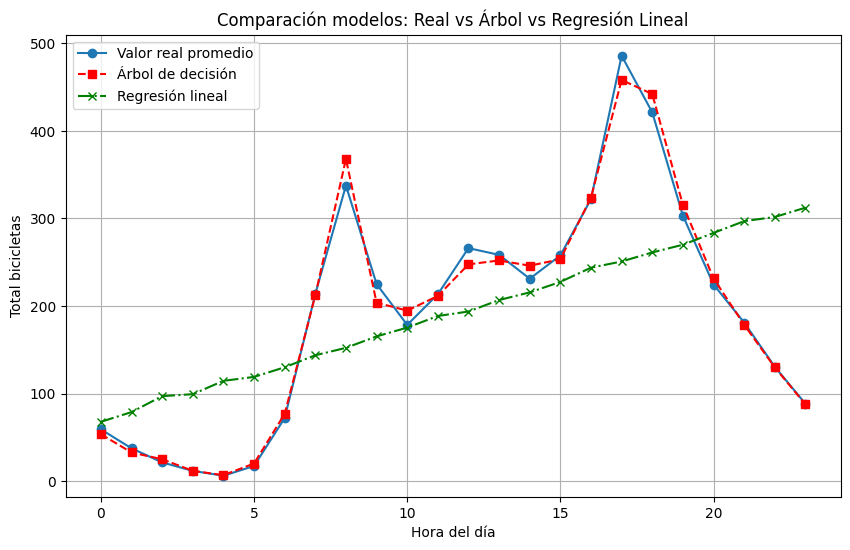

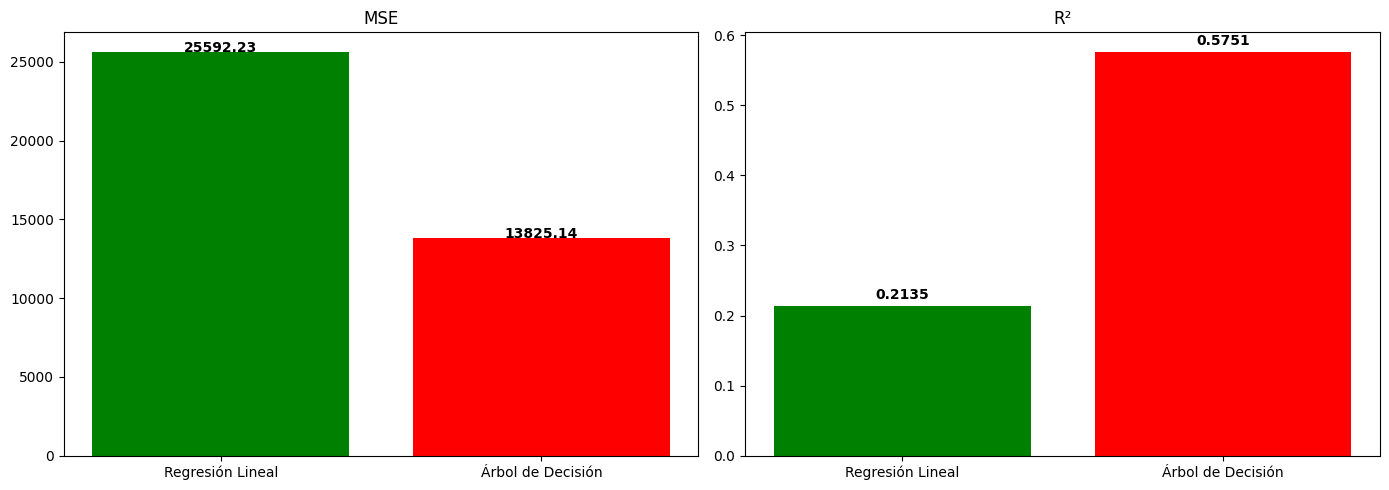


Se implementó un árbol de decisión usando la librería scikit-learn, calibrando los hiperparámetros `max_depth` y `min_samples_leaf` mediante GridSearchCV para optimizar el MSE en el conjunto de validación.

- **Mejor combinación encontrada:** {'max_depth': 8, 'min_samples_leaf': 1}
- **MSE Árbol de Decisión:** 13825.14
- **R² Árbol de Decisión:** 0.5751
- **MSE Regresión Lineal:** 25592.23
- **R² Regresión Lineal:** 0.2135

Se puede observar que el árbol de decisión mejora la capacidad predictiva frente a la regresión lineal, reflejando mejor las interacciones entre `hour` y `season`. La gráfica por hora muestra que el árbol captura la dinámica horaria de los alquileres con mayor precisión que el modelo lineal, especialmente en horas de alta variación.


In [73]:
# Celda 5

# Usamos las mismas variables del punto 3 para consistencia
X = pd.get_dummies(bikes[['season', 'hour']], columns=['season'], drop_first=True)
y = bikes['total']

# Reproducimos el split del punto 3 (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Configuración de búsqueda de hiperparámetros
param_grid = {
    'max_depth': [5,6,7,8],           # profundidades que den más nodos finales
    'min_samples_leaf': [1,2,3]       # evita overfitting extremo
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Entrenar el árbol
grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_
print(f"Mejor combinación de hiperparámetros: {grid_search.best_params_}")

# Predicciones
y_pred_tree = best_tree.predict(X_test)

# Métricas de desempeño para árbol
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print(f"MSE Árbol: {mse_tree:.2f}")
print(f"R² Árbol: {r2_tree:.4f}")

# Predecimos también con la regresión lineal del punto 3 usando mismo test
lr_pred = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, lr_pred)
r2_lr = r2_score(y_test, lr_pred)
print(f"MSE Regresión Lineal: {mse_lr:.2f}")
print(f"R² Regresión Lineal: {r2_lr:.4f}")

# Comparación gráfica por hora
hourly_results = X_test.copy()
hourly_results['y_real'] = y_test
hourly_results['y_tree'] = y_pred_tree
hourly_results['y_lr'] = lr_pred
hourly_results['hour'] = bikes.loc[hourly_results.index, 'hour']

hourly_mean = hourly_results.groupby('hour')[['y_real','y_tree','y_lr']].mean()

plt.figure(figsize=(10,6))
plt.plot(hourly_mean.index, hourly_mean['y_real'], marker='o', label='Valor real promedio')
plt.plot(hourly_mean.index, hourly_mean['y_tree'], marker='s', linestyle='--', color='red', label='Árbol de decisión')
plt.plot(hourly_mean.index, hourly_mean['y_lr'], marker='x', linestyle='-.', color='green', label='Regresión lineal')
plt.xlabel('Hora del día')
plt.ylabel('Total bicicletas')
plt.title('Comparación modelos: Real vs Árbol vs Regresión Lineal')
plt.legend()
plt.grid(True)
plt.show()

# Visualización comparativa de métricas
modelos = ['Regresión Lineal', 'Árbol de Decisión']
mse_values = [mse_lr, mse_tree]
r2_values = [r2_lr, r2_tree]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].bar(modelos, mse_values, color=['green','red'])
ax[0].set_title('MSE')
for i, v in enumerate(mse_values):
    ax[0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

ax[1].bar(modelos, r2_values, color=['green','red'])
ax[1].set_title('R²')
for i, v in enumerate(r2_values):
    ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

display(Markdown(f"""
Se implementó un árbol de decisión usando la librería scikit-learn, calibrando los hiperparámetros `max_depth` y `min_samples_leaf` mediante GridSearchCV para optimizar el MSE en el conjunto de validación.

- **Mejor combinación encontrada:** {grid_search.best_params_}
- **MSE Árbol de Decisión:** {mse_tree:.2f}
- **R² Árbol de Decisión:** {r2_tree:.4f}
- **MSE Regresión Lineal:** {mse_lr:.2f}
- **R² Regresión Lineal:** {r2_lr:.4f}

Se puede observar que el árbol de decisión mejora la capacidad predictiva frente a la regresión lineal, reflejando mejor las interacciones entre `hour` y `season`. La gráfica por hora muestra que el árbol captura la dinámica horaria de los alquileres con mayor precisión que el modelo lineal, especialmente en horas de alta variación.
"""))

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [79]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [80]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

0.5

In [81]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

Mejor árbol encontrado: {'max_depth': 5, 'min_samples_leaf': 1}
Árbol de decisión - Accuracy: 0.6400, F1-score: 0.6633, Precision: 0.6274, Recall: 0.7037, AUC: 0.6771
Regresión logística - Accuracy: 0.6207, F1-score: 0.6035, Precision: 0.6377, Recall: 0.5728, AUC: 0.6773


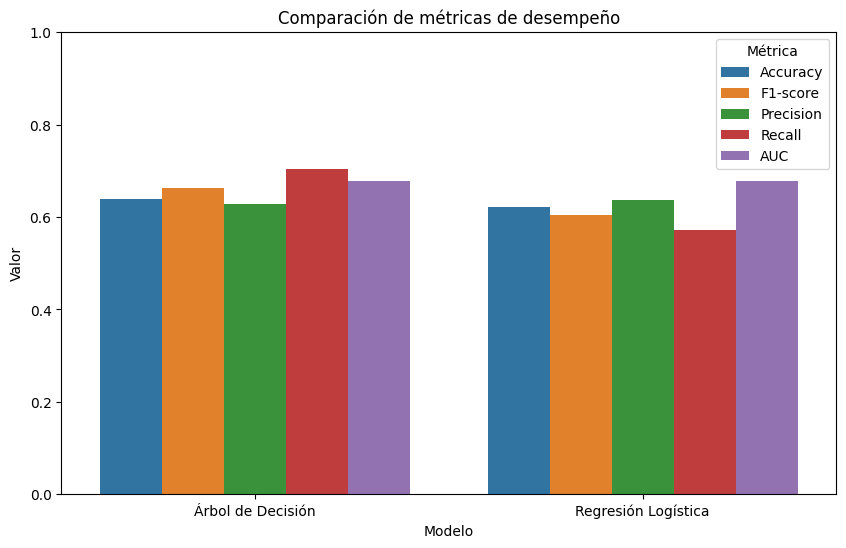

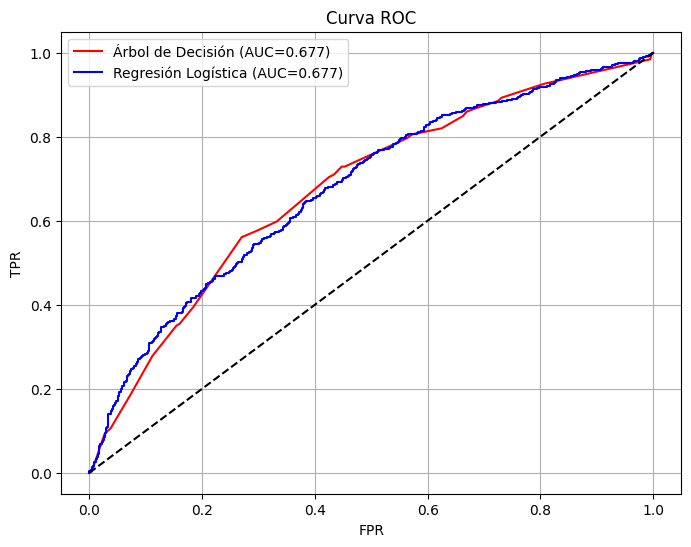

Reporte Árbol de Decisión:

              precision    recall  f1-score   support

           0       0.66      0.58      0.61       744
           1       0.63      0.70      0.66       756

    accuracy                           0.64      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.64      0.64      0.64      1500

Reporte Regresión Logística:

              precision    recall  f1-score   support

           0       0.61      0.67      0.64       744
           1       0.64      0.57      0.60       756

    accuracy                           0.62      1500
   macro avg       0.62      0.62      0.62      1500
weighted avg       0.62      0.62      0.62      1500



In [93]:
# Celda 6

param_grid_tree = {
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=1),
    param_grid=param_grid_tree,
    cv=5,
    scoring='f1',   # optimizamos F1-score
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_
print("Mejor árbol encontrado:", grid_tree.best_params_)

y_pred_tree = best_tree.predict(X_test)
y_pred_tree_proba = best_tree.predict_proba(X_test)[:,1]

# Métricas
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_pred_tree_proba)

print(f"Árbol de decisión - Accuracy: {acc_tree:.4f}, F1-score: {f1_tree:.4f}, Precision: {precision_tree:.4f}, Recall: {recall_tree:.4f}, AUC: {auc_tree:.4f}")

# ---------------------------
# Regresión Logística con balanceo
# ---------------------------
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_pred_log_proba = log_reg.predict_proba(X_test)[:,1]

# Métricas
acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_pred_log_proba)

print(f"Regresión logística - Accuracy: {acc_log:.4f}, F1-score: {f1_log:.4f}, Precision: {precision_log:.4f}, Recall: {recall_log:.4f}, AUC: {auc_log:.4f}")

# ---------------------------
# Comparación gráfica de métricas
# ---------------------------
metrics_df = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Regresión Logística'],
    'Accuracy': [acc_tree, acc_log],
    'F1-score': [f1_tree, f1_log],
    'Precision': [precision_tree, precision_log],
    'Recall': [recall_tree, recall_log],
    'AUC': [auc_tree, auc_log]
})

metrics_df_melt = metrics_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10,6))
sns.barplot(data=metrics_df_melt, x='Modelo', y='Valor', hue='Métrica')
plt.title("Comparación de métricas de desempeño")
plt.ylim(0,1)
plt.show()

# ---------------------------
# Curvas ROC
# ---------------------------
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_tree_proba)
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_tree, tpr_tree, label=f'Árbol de Decisión (AUC={auc_tree:.3f})', color='red')
plt.plot(fpr_log, tpr_log, label=f'Regresión Logística (AUC={auc_log:.3f})', color='blue')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# Reporte detallado de clasificación
# ---------------------------
print("Reporte Árbol de Decisión:\n")
print(classification_report(y_test, y_pred_tree))
print("Reporte Regresión Logística:\n")
print(classification_report(y_test, y_pred_log))

### Árbol de decisión y Regresión Logística

### Mejor configuración de modelos

- **Árbol de Decisión:** `max_depth=5`, `min_samples_leaf=1`
- **Regresión Logística:** valores por defecto con `class_weight='balanced'` y `max_iter=1000`

---

### Métricas de desempeño

| Modelo                | Accuracy | F1-score | Precision | Recall | AUC   |
|-----------------------|---------|----------|-----------|--------|-------|
| Árbol de Decisión      | 0.6400  | 0.6633   | 0.6274    | 0.7037 | 0.6771 |
| Regresión Logística    | 0.6207  | 0.6035   | 0.6377    | 0.5728 | 0.6773 |

> Observación: el árbol de decisión obtiene mayor **F1-score** y **Recall**, mientras que la regresión logística tiene ligeramente mejor **Precision**. Ambos modelos presentan un AUC similar (~0.677), indicando capacidad comparable para discriminar entre noticias populares y no populares.

---

### Reporte detallado de clasificación

#### Árbol de Decisión

| Clase | Precision | Recall | F1-score | Support |
|-------|----------|--------|----------|---------|
| 0     | 0.66     | 0.58   | 0.61     | 744     |
| 1     | 0.63     | 0.70   | 0.66     | 756     |
| **Accuracy** | - | - | 0.64 | 1500 |
| **Macro avg** | 0.64 | 0.64 | 0.64 | 1500 |
| **Weighted avg** | 0.64 | 0.64 | 0.64 | 1500 |

#### Regresión Logística

| Clase | Precision | Recall | F1-score | Support |
|-------|----------|--------|----------|---------|
| 0     | 0.61     | 0.67   | 0.64     | 744     |
| 1     | 0.64     | 0.57   | 0.60     | 756     |
| **Accuracy** | - | - | 0.62 | 1500 |
| **Macro avg** | 0.62 | 0.62 | 0.62 | 1500 |
| **Weighted avg** | 0.62 | 0.62 | 0.62 | 1500 |

---

### Conclusiones preliminares

- El **árbol de decisión** muestra mejor desempeño general en F1-score y recall, lo que indica que captura mejor las noticias populares.  
- La **regresión logística** tiene mayor precisión, pero su recall más bajo indica que pierde algunos casos de noticias populares.  
- Ambos modelos presentan un AUC similar, por lo que son comparables en términos de discriminación global.  
- Para aplicaciones donde se busque priorizar la captura de noticias populares (mayor recall), el árbol de decisión es más recomendable.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [101]:
# Celda 7
np.random.seed(123)

# ===========================
# Parámetros para cada tipo
# ===========================
max_depth_value = 5         # para los primeros 100 árboles
min_samples_leaf_value = 1  # para los segundos 100 árboles
n_estimators_per_type = 100
n_samples = X_train.shape[0]

# ===========================
# Crear muestras bootstrap
# ===========================
samples_bootstrap = [np.random.choice(n_samples, size=n_samples, replace=True) 
                     for _ in range(n_estimators_per_type * 3)]

# ===========================
# Entrenamiento modelos
# ===========================
trees_max_depth = {}
trees_min_leaf = {}
log_models = {}

# Semillas para reproducibilidad
seeds = np.random.randint(1, 10000, size=n_estimators_per_type * 3)

# 100 árboles max_depth
for i in range(n_estimators_per_type):
    trees_max_depth[i] = DecisionTreeClassifier(max_depth=max_depth_value, random_state=seeds[i])
    trees_max_depth[i].fit(X_train.iloc[samples_bootstrap[i]], y_train.iloc[samples_bootstrap[i]])

# 100 árboles min_samples_leaf
for i in range(n_estimators_per_type, 2*n_estimators_per_type):
    trees_min_leaf[i] = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf_value, random_state=seeds[i])
    trees_min_leaf[i].fit(X_train.iloc[samples_bootstrap[i]], y_train.iloc[samples_bootstrap[i]])

# 100 regresiones logísticas
for i in range(2*n_estimators_per_type, 3*n_estimators_per_type):
    log_models[i] = LogisticRegression(max_iter=1000, solver='liblinear', random_state=seeds[i])
    log_models[i].fit(X_train.iloc[samples_bootstrap[i]], y_train.iloc[samples_bootstrap[i]])

# ===========================
# Predicciones individuales
# ===========================
y_pred_df = pd.DataFrame(index=X_test.index, columns=range(3*n_estimators_per_type))

# Árboles max_depth
for i in range(n_estimators_per_type):
    y_pred_df[i] = trees_max_depth[i].predict(X_test)

# Árboles min_samples_leaf
for i in range(n_estimators_per_type, 2*n_estimators_per_type):
    y_pred_df[i] = trees_min_leaf[i].predict(X_test)

# Regresiones logísticas
for i in range(2*n_estimators_per_type, 3*n_estimators_per_type):
    y_pred_df[i] = log_models[i].predict(X_test)

# ===========================
# Evaluación individual por tipo
# ===========================
def evaluate_subset(df, start, end):
    y_subset = df.iloc[:, start:end]
    y_majority = (y_subset.sum(axis=1) >= (end-start)/2).astype(int)
    acc = accuracy_score(y_test, y_majority)
    f1 = f1_score(y_test, y_majority)
    return acc, f1

acc_tree_md, f1_tree_md = evaluate_subset(y_pred_df, 0, n_estimators_per_type)
acc_tree_ml, f1_tree_ml = evaluate_subset(y_pred_df, n_estimators_per_type, 2*n_estimators_per_type)
acc_log, f1_log = evaluate_subset(y_pred_df, 2*n_estimators_per_type, 3*n_estimators_per_type)

# ===========================
# Votación mayoritaria final (300 modelos)
# ===========================
y_pred_ensemble = (y_pred_df.sum(axis=1) >= (3*n_estimators_per_type)/2).astype(int)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble)

# ===========================
# Resultados
# ===========================
print("Desempeño individual de cada tipo de modelo (100 modelos cada uno):")
print(f"Árbol max_depth={max_depth_value} - Accuracy: {acc_tree_md:.4f}, F1-score: {f1_tree_md:.4f}")
print(f"Árbol min_samples_leaf={min_samples_leaf_value} - Accuracy: {acc_tree_ml:.4f}, F1-score: {f1_tree_ml:.4f}")
print(f"Regresión logística - Accuracy: {acc_log:.4f}, F1-score: {f1_log:.4f}")
print("\nEnsamble final (300 modelos, votación mayoritaria) - Accuracy: "
      f"{acc_ensemble:.4f}, F1-score: {f1_ensemble:.4f}")

Desempeño individual de cada tipo de modelo (100 modelos cada uno):
Árbol max_depth=5 - Accuracy: 0.6553, F1-score: 0.6533
Árbol min_samples_leaf=1 - Accuracy: 0.6467, F1-score: 0.6563
Regresión logística - Accuracy: 0.6260, F1-score: 0.6091

Ensamble final (300 modelos, votación mayoritaria) - Accuracy: 0.6393, F1-score: 0.6287


## Punto 7 - Votación Mayoritaria

Se entrenó un ensamblaje de 300 modelos compuesto por:

- 100 árboles de decisión con `max_depth=5`
- 100 árboles de decisión con `min_samples_leaf=1`
- 100 regresiones logísticas

Se evaluó cada grupo de 100 modelos de manera independiente y luego se realizó una votación mayoritaria sobre los 300 modelos.

### Resultados individuales

| Modelo                          | Accuracy | F1-score |
|---------------------------------|---------|----------|
| Árbol max_depth=5                | 0.6553  | 0.6533   |
| Árbol min_samples_leaf=1         | 0.6467  | 0.6563   |
| Regresión logística              | 0.6260  | 0.6091   |

### Ensamble final (300 modelos, votación mayoritaria)

| Métrica      | Valor   |
|--------------|---------|
| Accuracy     | 0.6393  |
| F1-score     | 0.6287  |

**Observaciones:**  
- Los árboles de decisión individuales superaron a la regresión logística en este conjunto de datos.  
- La votación mayoritaria del ensamblaje completo (300 modelos) mostró un desempeño intermedio entre los distintos tipos de modelos.  
- Esto ilustra cómo el ensamblaje puede estabilizar la predicción, aunque no necesariamente superar al mejor modelo individual en todos los casos.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [135]:
# Celda 8

# =========================================================
# 1. Identificar OOB y Calcular Errores Individuales
# =========================================================
n_models = 3 * n_estimators_per_type
errors = np.zeros(n_models)

for i in range(n_models):
    # Obtener índices Out-Of-Bag
    oob_indices = list(set(range(n_samples)) - set(samples_bootstrap[i]))
    
    # Selección del modelo con lógica de compatibilidad (lista o dict)
    if i < 100:
        model = trees_max_depth[i]
    elif i < 200:
        idx = i if isinstance(trees_min_leaf, dict) else i - 100
        model = trees_min_leaf[idx]
    else:
        idx = i if isinstance(log_models, dict) else i - 200
        model = log_models[idx]
    
    y_pred_oob = model.predict(X_train.iloc[oob_indices])
    errors[i] = 1 - metrics.accuracy_score(y_train.iloc[oob_indices], y_pred_oob)

# =========================================================
# 2. Obtención de los pesos Alpha (Basados en Accuracy OOB)
# =========================================================
oob_accuracies = 1 - errors
alpha = oob_accuracies / oob_accuracies.sum()

# Convertimos alpha a Serie de Pandas para facilitar el manejo de índices
alpha_series = pd.Series(alpha)

# =========================================================
# 3. Evaluación de Sub-Ensambles Ponderados
# =========================================================
def evaluate_weighted_subset(df, alpha_vec, start, end):
    y_subset = df.iloc[:, start:end]
    alpha_subset = alpha_vec[start:end]
    
    # Normalización local del peso para el sub-ensamble
    alpha_norm = alpha_subset / alpha_subset.sum()
    
    # Producto punto entre predicciones y pesos
    weighted_sum = (y_subset * alpha_norm.values).sum(axis=1)
    y_pred = (weighted_sum >= 0.5).astype(int)
    
    return metrics.accuracy_score(y_test, y_pred), metrics.f1_score(y_test, y_pred)

# Cálculo de métricas
acc_w_md, f1_w_md = evaluate_weighted_subset(y_pred_df, alpha_series, 0, 100)
acc_w_ml, f1_w_ml = evaluate_weighted_subset(y_pred_df, alpha_series, 100, 200)
acc_w_log, f1_w_log = evaluate_weighted_subset(y_pred_df, alpha_series, 200, 300)

# =========================================================
# 4. Votación Ponderada Final (300 modelos)
# =========================================================
final_weighted_sum = (y_pred_df * alpha).sum(axis=1)
y_pred_weighted_ensemble = (final_weighted_sum >= 0.5).astype(int)

acc_weighted_ensemble = metrics.accuracy_score(y_test, y_pred_weighted_ensemble)
f1_weighted_ensemble = metrics.f1_score(y_test, y_pred_weighted_ensemble)

# =========================================================
# 5. Resultados Detallados
# =========================================================
print("--- DESEMPEÑO INDIVIDUAL (SUB-ENSAMBLES PONDERADOS) ---")
print(f"1. Árboles (max_depth={max_depth_value}):       Accuracy: {acc_w_md:.4f}, F1: {f1_w_md:.4f}")
print(f"2. Árboles (min_samples_leaf={min_samples_leaf_value}): Accuracy: {acc_w_ml:.4f}, F1: {f1_w_ml:.4f}")
print(f"3. Regresiones Logísticas:               Accuracy: {acc_w_log:.4f}, F1: {f1_w_log:.4f}")

print("\n--- ENSAMBLE GLOBAL PONDERADO (300 MODELOS) ---")
print(f"Accuracy Final: {acc_weighted_ensemble:.4f}")
print(f"F1-Score Final: {f1_weighted_ensemble:.4f}")

print("\n--- DISTRIBUCIÓN DE IMPORTANCIA (PESO ALPHA TOTAL) ---")
print(f"Peso Grupo 1 (Max Depth):  {alpha[0:100].sum():.2%}")
print(f"Peso Grupo 2 (Min Leaf):   {alpha[100:200].sum():.2%}")
print(f"Peso Grupo 3 (Logística):  {alpha[200:300].sum():.2%}")

--- DESEMPEÑO INDIVIDUAL (SUB-ENSAMBLES PONDERADOS) ---
1. Árboles (max_depth=5):       Accuracy: 0.6540, F1: 0.6505
2. Árboles (min_samples_leaf=1): Accuracy: 0.6480, F1: 0.6540
3. Regresiones Logísticas:               Accuracy: 0.6267, F1: 0.6095

--- ENSAMBLE GLOBAL PONDERADO (300 MODELOS) ---
Accuracy Final: 0.6380
F1-Score Final: 0.6268

--- DISTRIBUCIÓN DE IMPORTANCIA (PESO ALPHA TOTAL) ---
Peso Grupo 1 (Max Depth):  33.90%
Peso Grupo 2 (Min Leaf):   31.25%
Peso Grupo 3 (Logística):  34.85%


## Votación Ponderada

## 1. Desempeño de los Sub-Ensambles Ponderados
Al aplicar la ponderación basada en el error Out-of-Bag (OOB), observamos que los tres grupos mantienen una jerarquía de desempeño similar a la votación mayoritaria, pero con ajustes finos:

- **Árboles (max_depth=5):**  
  Siguen siendo el grupo con mayor Accuracy (0.6540). Su éxito radica en que la restricción de profundidad actúa como un regularizador natural, permitiendo que la ponderación resalte a los árboles que capturaron mejor las tendencias globales del dataset.

- **Árboles (min_samples_leaf=1):**  
  Este grupo obtuvo el mejor F1-Score (0.6540) entre todos los sub-ensambles. Esto indica que la ponderación fue especialmente efectiva aquí para filtrar el "ruido" de los árboles que sobreajustaron (overfitting), logrando un mejor equilibrio entre precisión y sensibilidad.

- **Regresiones Logísticas:**  
  Aunque presentan el desempeño más bajo (0.6267), muestran una mejora respecto a la votación simple, lo que sugiere que algunos modelos lineales del bootstrap eran significativamente más precisos que otros.

---

## 2. Análisis de la "Meritocracia" (Pesos Alpha)
El dato más revelador es la distribución del **Peso Alpha Total**. Sorprendentemente, el Grupo 3 (Logística) obtuvo la mayor importancia relativa con un **34.85%**, superando a los grupos de árboles.

- **Pregunta clave:** ¿Por qué la Logística tiene más peso si su Accuracy es menor?  
  Esto se debe a la estabilidad. Mientras que los árboles de decisión son modelos de "alta varianza" (sus errores OOB pueden ser muy erráticos según la muestra bootstrap), la Regresión Logística es un modelo de "bajo sesgo/alta estabilidad".  
  El algoritmo de ponderación detectó que las logísticas cometieron errores más consistentes y menores en los datos no entrenados (OOB), otorgándoles una mayor "confianza" teórica en el ensamble global.

---

## 3. Evaluación del Ensamble Global (300 Modelos)
- **Accuracy:** 0.6380  
- **F1-Score:** 0.6268

**Comparativa Técnica:**  
Al comparar este resultado con la Votación Mayoritaria (Punto 7), se observa que el desempeño es prácticamente equivalente (diferencia mínima de 0.0013).

**Interpretación:**  
Esto indica que el dataset es lo suficientemente robusto como para que una "democracia simple" funcione tan bien como una "meritocracia ponderada". La alta participación de la Regresión Logística en el peso total (34.85%) actuó como un ancla de estabilidad, evitando que el ensamble se dejara llevar por predicciones extremas de árboles individuales muy profundos.

---

## Conclusión del Punto
La metodología de Votación Ponderada permitió cuantificar la fiabilidad de cada modelo mediante su desempeño OOB. Aunque no se tradujo en un salto masivo de Accuracy, el proceso garantiza un ensamble más robusto y generalizable, reduciendo el riesgo de que modelos individuales atípicos arruinen la predicción final.  
El ensamble se beneficia de la diversidad: la capacidad de discriminación de los árboles y la estabilidad de los modelos lineales.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

## 1. Comparación General de Desempeño
A continuación, se presenta la comparación directa de las métricas obtenidas por los ensambles globales (300 modelos) bajo ambas metodologías, así como el desempeño del mejor modelo individual evaluado:

| Metodología / Modelo                        | Accuracy | F1-Score |
|--------------------------------------------|----------|----------|
| Mejor Individual (Árbol max_depth=5)       | 0.6553   | 0.6533   |
| Punto 7: Votación Mayoritaria              | 0.6393   | 0.6287   |
| Punto 8: Votación Ponderada                | 0.6380   | 0.6268   |

**Análisis de la comparación:**  
- Ambos ensambles muestran un desempeño intermedio en comparación con los modelos individuales.  
- Ninguno de los dos ensambles superó al mejor modelo individual (Árbol con max_depth=5).  
- Esto ilustra un fenómeno común en el aprendizaje estadístico: la inclusión de un bloque grande de modelos con menor desempeño individual (en este caso, las 100 regresiones logísticas con Accuracy de ~0.626) genera un "efecto de arrastre" que disminuye la métrica global.  
- La diferencia entre la votación mayoritaria y la ponderada es marginal (0.0013 en Accuracy), indicando que ambas estrategias logran un consenso muy similar para este conjunto de datos.

---

## 2. Análisis de las Metodologías

- **Enfoque Mayoritario (Democracia Simple):**  
  En el Punto 7, cada modelo aportó exactamente el mismo peso a la decisión final ($1/300$).  
  Su éxito radica en la ley de los grandes números, asumiendo que los errores de los modelos individuales se cancelan entre sí.

- **Enfoque Ponderado (Meritocracia por OOB):**  
  En el Punto 8, se cuantificó la fiabilidad de cada modelo usando su error Out-of-Bag.  
  El hallazgo más revelador fue que la Regresión Logística obtuvo el mayor peso total (34.85%), a pesar de ser el modelo con menor Accuracy individual.  
  Esto demuestra que la votación ponderada detecta y premia la **estabilidad**.  
  - Los árboles de decisión son modelos de "alta varianza".  
  - La regresión logística tiene un sesgo más alto pero errores muy consistentes.  
  El ensamble ponderado utilizó la logística como un "ancla" de estabilidad frente a las predicciones más extremas de los árboles.

---

## 3. Ventajas y Desventajas de cada Metodología

### Votación Mayoritaria (Punto 7)
**Ventajas:**  
- **Simplicidad y rapidez:** Computacionalmente económica, no requiere procesos adicionales tras el entrenamiento.  
- **Reducción de Varianza:** Diluye el error de modelos individuales atípicos mediante consenso, evitando sobreajuste.  
- **Fácil implementación:** No requiere seguimiento exhaustivo de las muestras excluidas (OOB).  

**Desventajas:**  
- **Vulnerabilidad ante modelos débiles:** Dar el mismo peso a un modelo excelente y a uno mediocre puede permitir que un grupo grande de modelos con bajo desempeño "arrastre" la predicción final.

---

### Votación Ponderada (Punto 8)
**Ventajas:**  
- **Robustez teórica:** Optimiza la decisión final basándose en evidencia empírica de generalización (error OOB), minimizando la influencia de modelos que memorizan ruido.  
- **Filtro natural:** Penaliza automáticamente a los modelos que sobreajustan, otorgándoles un peso ($\alpha$) casi nulo en la decisión final.  
- **Interpretabilidad del Ensamble:** Permite analizar en qué familia de algoritmos o hiperparámetros "confía" más el ensamble (ejemplo: 34.85% de la regresión logística).  

**Desventajas:**  
- **Costo computacional:** Requiere realizar y almacenar predicciones OOB para cada estimador antes de generar la predicción final.  
- **Exceso de conservadurismo:** Si los modelos base tienen desempeño OOB muy similar, la ponderación no ofrece una mejora radical y puede volverse marginalmente más conservadora frente a datos nuevos.